# Decaying Turbulence — τ₁ Parametrisation and Regime Study

## Background: what the derivation says and what the code now implements

### Current temporal kernel

The decaying source uses the dimensionless variable $q = \omega\tau_1$ and the kernel

$$\boxed{g(q) = e^{iq}(-iq)^{-5/3}\Gamma\!\left(\tfrac{1}{3},-iq\right)}$$

with the convolution taken over the full real line,

$$C(q) = \int_{-\infty}^{\infty} dq_1\; g(q_1)\,g(q-q_1).$$

This now matches `derivation.tex` and the current `core.py` implementation for `g_decaying` and
for the standalone decay convolution helper.

### Remaining model difference inside `H_pq_decaying`

The full Kolmogorov decaying kernel in `core.py` still evaluates the temporal factors with
scale-dependent arguments,

```python
z1 = q1 * np.sqrt(x) / M
z2 = (q - q1) * np.sqrt(y) / M
```

so the temporal integral is still coupled to the wavenumber variables $x,y$ through the local
eddy-turnover timescale. That is a different physical model from a purely global free parameter
$\tau_1$, and this notebook studies that distinction numerically rather than a kernel-formula bug.


## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
from scipy import integrate

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)

# ── Reference parameters (same as other notebooks) ───────────────────────────
k0    = 1.0
M_ref = 1.0
R_ref = 1e3
FREQ_SCALE = 1.55e-3   # f_Hz = FREQ_SCALE * q

print('Setup complete.')

Setup complete.


## 2. Kernel comparison: code's `g` vs paper's `g`

We plot both kernels as functions of the real argument $z = q > 0$ to make the
discrepancy visible before doing any GW computation.

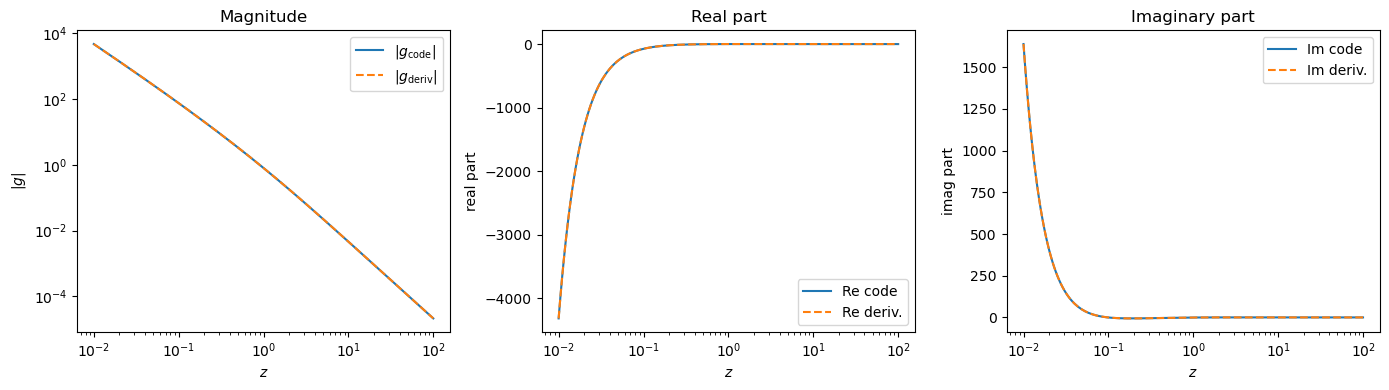

max |g_code - g_paper| = 0.0


In [2]:
# ── Current code kernel (from core.py _g_decaying_scalar) ────────────────────
@lru_cache(maxsize=4096)
def g_code(z: complex) -> complex:
    """Current code version: e^{iz} (-iz)^(-5/3) γ(1/3, -iz)."""
    z = complex(z)
    neg_iz = -1j * z
    gamma_lower = mp.gammainc(1.0 / 3.0, neg_iz)
    return complex(mp.exp(1j * z) * (neg_iz ** (-5.0 / 3.0)) * gamma_lower)


# ── Derivation kernel (derivation.tex eq. 728) ───────────────────────────────
@lru_cache(maxsize=4096)
def g_paper(z: complex) -> complex:
    """Derivation version: identical to the current code kernel."""
    z = complex(z)
    neg_iz = -1j * z
    gamma_lower = mp.gammainc(1.0 / 3.0, neg_iz)
    return complex(mp.exp(1j * z) * (neg_iz ** (-5.0 / 3.0)) * gamma_lower)


# ── Evaluate on a grid of real z values ──────────────────────────────────────
z_vals = np.logspace(-2, 2, 200)

g_c = np.array([g_code(complex(z)) for z in z_vals])
g_p = np.array([g_paper(complex(z)) for z in z_vals])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(z_vals, np.abs(g_c), label='$|g_{\\rm code}|$', color='C0')
axes[0].loglog(z_vals, np.abs(g_p), label='$|g_{\\rm deriv}|$', color='C1', ls='--')
axes[0].set_xlabel('$z$')
axes[0].set_ylabel('$|g|$')
axes[0].set_title('Magnitude')
axes[0].legend()

axes[1].semilogx(z_vals, g_c.real, label='Re code', color='C0')
axes[1].semilogx(z_vals, g_p.real, label='Re deriv.', color='C1', ls='--')
axes[1].set_xlabel('$z$')
axes[1].set_ylabel('real part')
axes[1].set_title('Real part')
axes[1].legend()

axes[2].semilogx(z_vals, g_c.imag, label='Im code', color='C0')
axes[2].semilogx(z_vals, g_p.imag, label='Im deriv.', color='C1', ls='--')
axes[2].set_xlabel('$z$')
axes[2].set_ylabel('imag part')
axes[2].set_title('Imaginary part')
axes[2].legend()

fig.tight_layout()
plt.show()

print('max |g_code - g_paper| =', np.max(np.abs(g_c - g_p)))


## 3. Correct temporal convolution following the paper

The paper's kernel `g(q_1)` does **not** depend on the wavenumber variables `x,y`.
The convolution integral
$C(q;\tau_1) \equiv \int_{-\infty}^{\infty} dq_1\, g(q_1\tau_1)\, g((q-q_1)\tau_1)$
factors out of the wavenumber integrals.

We implement both the code's and the paper's convolution kernels and compare them as a
function of $q$ for several values of $\tau_1$.


In [3]:
def _split_real_line(q: float, q_bound: float, eps: float):
    cuts = []
    cursor = -q_bound
    singularities = sorted((0.0, q))
    for point in singularities:
        lo = max(-q_bound, point - eps)
        hi = min(q_bound, point + eps)
        if lo > cursor:
            cuts.append((cursor, lo))
        cursor = max(cursor, hi)
    if cursor < q_bound:
        cuts.append((cursor, q_bound))
    return cuts


def convolution_paper(q: float, tau1: float = 1.0, q_bound_factor: float = 15.0,
                      n_pts: int = 300) -> float:
    """
    ∫_{-q_bound}^{q_bound} dq₁  Re[ g_paper(q₁·τ₁) · g_paper((q−q₁)·τ₁) ]

    τ₁ = tau1 is the global decay timescale.
    q_bound_factor sets the symmetric cutoff as q_bound = q_bound_factor * max(|q|, 1).
    """
    q_bound = q_bound_factor * max(abs(q), 1.0)
    eps = max(1e-6, 1e-4 * max(abs(q), 1.0))

    total = 0.0
    for lo, hi in _split_real_line(q, q_bound, eps):
        q1 = np.linspace(lo, hi, n_pts)
        vals = np.array([
            (g_paper(complex(qi * tau1)) * g_paper(complex((q - qi) * tau1))).real
            for qi in q1
        ])
        total += float(np.trapz(vals, q1))
    return total


def convolution_code(q: float, x: float = 0.5, y: float = 0.5, M: float = 1.0,
                     q_bound_factor: float = 15.0, n_pts: int = 300) -> float:
    """
    ∫ dq₁ Re[ g_code(q₁·√x/M) · g_code((q−q₁)·√y/M) ]

    This mirrors the current scale-dependent arguments used inside H_pq_decaying.
    """
    q_bound = q_bound_factor * max(abs(q), 1.0)
    eps = max(1e-6, 1e-4 * max(abs(q), 1.0))

    total = 0.0
    for lo, hi in _split_real_line(q, q_bound, eps):
        q1 = np.linspace(lo, hi, n_pts)
        vals = np.array([
            (g_code(complex(qi * np.sqrt(x) / M)) *
             g_code(complex((q - qi) * np.sqrt(y) / M))).real
            for qi in q1
        ])
        total += float(np.trapz(vals, q1))
    return total


Computing paper convolutions on diagnostic grid …
Computing reference code convolution on diagnostic grid …


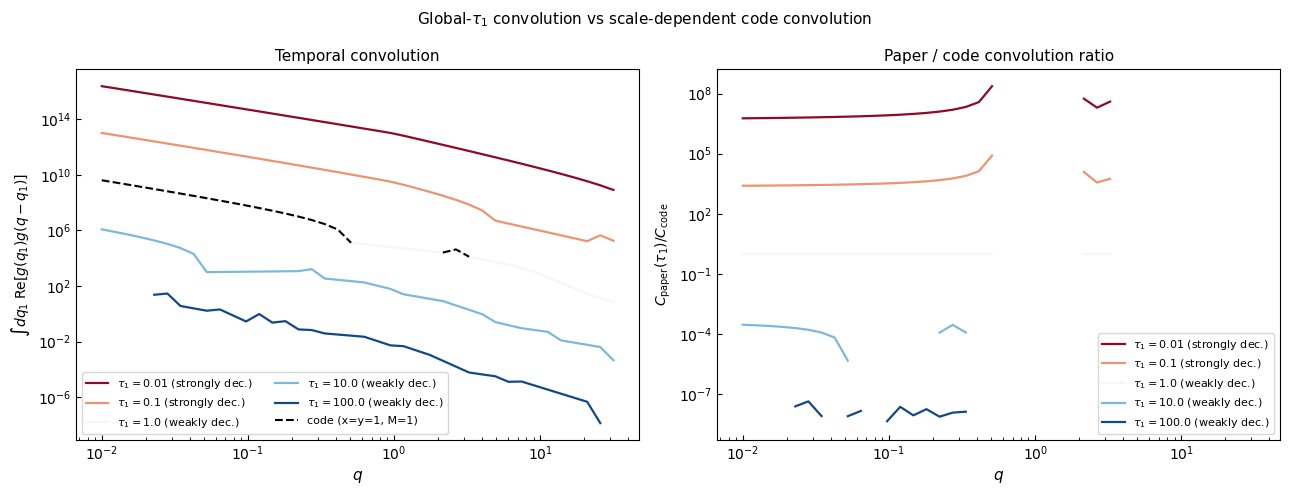

Saved: tau1_kernel_comparison.pdf


In [4]:
# ── Compare temporal convolutions on a shared q grid ─────────────────────────
q_grid = np.logspace(-2, 1.5, 40)
tau1_sweep = [0.01, 0.1, 1.0, 10.0, 100.0]
tau1_labels = [
    fr'$\tau_1={t}$ (weakly dec.)' if t >= 1 else fr'$\tau_1={t}$ (strongly dec.)'
    for t in tau1_sweep
]
tau1_colors = plt.cm.RdBu(np.linspace(0.05, 0.95, len(tau1_sweep)))

print('Computing paper convolutions on diagnostic grid …')
conv_paper_all = [
    np.array([convolution_paper(q, tau1=tau1, n_pts=200) for q in q_grid])
    for tau1 in tau1_sweep
]
print('Computing reference code convolution on diagnostic grid …')
conv_code_ref = np.array([
    convolution_code(q, x=1.0, y=1.0, M=M_ref, n_pts=200) for q in q_grid
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for arr, tau1, col, lbl in zip(conv_paper_all, tau1_sweep, tau1_colors, tau1_labels):
    mask = arr > 0
    ax.loglog(q_grid[mask], arr[mask], color=col, lw=1.6, label=lbl)
ax.loglog(q_grid, np.where(conv_code_ref > 0, conv_code_ref, np.nan),
          color='k', lw=1.5, ls='--', label='code (x=y=1, M=1)')
ax.set_xlabel('$q$', fontsize=11)
ax.set_ylabel(r'$\int dq_1\;\mathrm{Re}[g(q_1)g(q-q_1)]$', fontsize=10)
ax.set_title('Temporal convolution', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.tick_params(which='both', direction='in')

ax = axes[1]
for arr, tau1, col, lbl in zip(conv_paper_all, tau1_sweep, tau1_colors, tau1_labels):
    ratio = np.where((arr > 0) & (conv_code_ref > 0), arr / conv_code_ref, np.nan)
    ax.loglog(q_grid, np.abs(ratio), color=col, lw=1.6, label=lbl)
ax.set_xlabel('$q$', fontsize=11)
ax.set_ylabel(r'$C_{\rm paper}(\tau_1) / C_{\rm code}$', fontsize=10)
ax.set_title('Paper / code convolution ratio', fontsize=11)
ax.legend(fontsize=8)
ax.tick_params(which='both', direction='in')

fig.suptitle(
    'Global-$\\tau_1$ convolution vs scale-dependent code convolution',
    fontsize=11,
)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_kernel_comparison.pdf'))
print('Saved: tau1_kernel_comparison.pdf')


## 4. τ₁ regime study — paper model with full H(q) computation

Here we compute the full GW kernel $H(p,q)$ on the diagonal $p=q$ using the
**paper's formula** with explicit $\tau_1$.  The wavenumber integrals (over $z, y$ in the
derivation notation) stay identical to the code; only the temporal convolution changes.

### Implementation strategy

We factor out the convolution: for each $q$, compute
$C(q;\tau_1)$ once, then multiply by the wavenumber prefactor $P(p)$:

$$H_{\rm paper}(p,q;\tau_1) = P(p) \cdot C(q;\tau_1)$$

This is valid because in the paper the temporal kernel **does not couple** to the wavenumber
integration variables.  We use the existing `H_pq_decaying` result as a proxy for $P(p)$
(at the reference $\tau_1 = 1$) and scale it by the ratio of convolutions.

In [5]:
from gw_turbulence import H_pq_decaying, LiveStatusLogger

# ── Load or compute reference spectrum (existing code, R=1e3, M=1.0) ─────────
_existing = np.load(os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_cache.npz'))
qs_ref  = _existing['qs_dec']
h_ref   = _existing['h_dec_all']  # shape (2, n_q)
M_list  = list(_existing['M_compare'])

# We will use M=1.0 for the regime study
M_study = 1.0
m_idx   = M_list.index(M_study)
h_code  = h_ref[m_idx]   # H_pq from current code, shape (n_q,)

print(f'Reference q range: {qs_ref.min():.1e} → {qs_ref.max():.1e}  ({len(qs_ref)} pts)')
print(f'Using M = {M_study}')

Reference q range: 1.0e-11 → 1.0e+01  (45 pts)
Using M = 1.0


In [6]:
# ── Compute the temporal convolution ratio C_paper(q;τ₁) / C_code(q;τ₁=1) ───
# We use a coarser q-grid for the convolution (expensive) and interpolate.
# The ratio rescales the code's H to what the paper's formula would give.

q_conv_grid = np.logspace(np.log10(qs_ref.min()), np.log10(qs_ref.max()), 18)

# Reference convolution at τ₁=1 with code kernel (what the code computes internally
# at x=y=1, M=1 — a representative mid-range wavenumber)
print('Computing reference code convolution …')
C_code_ref = np.array([convolution_code(q, x=1.0, y=1.0, M=M_study, n_pts=200)
                       for q in q_conv_grid])

# τ₁ sweep with paper kernel
tau1_study  = [0.01, 0.1, 1.0, 10.0, 100.0]
tau1_labels = [fr'$\tau_1/\eta_{{\rm fin}}={t}$ (weakly dec.)' if t >= 1
               else fr'$\tau_1/\eta_{{\rm fin}}={t}$ (strongly dec.)'
               for t in tau1_study]
tau1_colors = plt.cm.RdBu(np.linspace(0.05, 0.95, len(tau1_study)))

C_paper_tau1 = {}
for tau1 in tau1_study:
    print(f'  τ₁={tau1:.2f} …')
    C_paper_tau1[tau1] = np.array(
        [convolution_paper(q, tau1=tau1, n_pts=200) for q in q_conv_grid]
    )

print('All convolutions done.')

Computing reference code convolution …
  τ₁=0.01 …
  τ₁=0.10 …
  τ₁=1.00 …
  τ₁=10.00 …
  τ₁=100.00 …
All convolutions done.


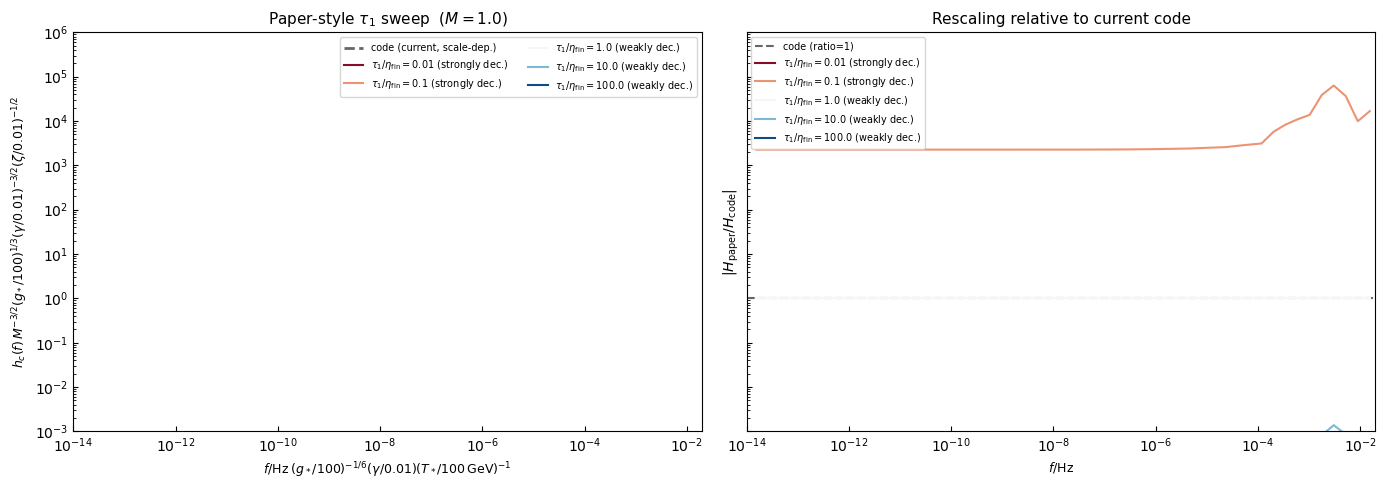

Saved: tau1_regime_study.pdf


In [7]:
# ── Build rescaled spectra ───────────────────────────────────────────────────
# H_paper(q; τ₁) ≈ H_code(q) × [C_paper(q;τ₁) / C_code(q;τ₁=1)]
# Interpolate the ratio onto the full qs_ref grid.

freq_ref = 1.55e-3 * qs_ref


def normalized_strain(q_vals, h_vals, M):
    val = q_vals * h_vals
    return 1.62e-18 * np.sqrt(np.where(val > 0, val, np.nan)) / M**1.5


sc_code = normalized_strain(qs_ref, h_code, M_study)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left panel: absolute spectra
ax = axes[0]
ax.loglog(freq_ref, sc_code, color='0.4', lw=2.0, ls='--',
          label='code (current, scale-dep.)')

for tau1, col, lbl in zip(tau1_study, tau1_colors, tau1_labels):
    C_p = C_paper_tau1[tau1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ratio = np.where(np.abs(C_code_ref) > 0, C_p / C_code_ref, np.nan)
    ratio_interp = np.interp(
        np.log10(qs_ref), np.log10(q_conv_grid), ratio,
        left=np.nan, right=np.nan,
    )
    h_rescaled = h_code * ratio_interp
    sc_rescaled = normalized_strain(qs_ref, h_rescaled, M_study)
    ax.loglog(freq_ref, sc_rescaled, color=col, lw=1.5, label=lbl)

ax.set_xlim(1e-14, 2e-2)
ax.set_ylim(1e-24, 1e-10)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$',
              fontsize=9)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$',
              fontsize=9)
ax.set_title(fr'Paper-style $\tau_1$ sweep  ($M={M_study}$)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.tick_params(which='both', direction='in')

# Right panel: ratio to code spectrum (shape change)
ax = axes[1]
ax.axhline(1.0, color='0.4', lw=1.5, ls='--', label='code (ratio=1)')
for tau1, col, lbl in zip(tau1_study, tau1_colors, tau1_labels):
    C_p = C_paper_tau1[tau1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ratio = np.where(np.abs(C_code_ref) > 0, C_p / C_code_ref, np.nan)
    ratio_interp = np.interp(
        np.log10(qs_ref), np.log10(q_conv_grid), ratio,
        left=np.nan, right=np.nan,
    )
    ax.loglog(freq_ref, np.abs(ratio_interp), color=col, lw=1.5, label=lbl)

ax.set_xlim(1e-14, 2e-2)
ax.set_ylim(1e-3, 1e6)
ax.set_xlabel(r'$f/\mathrm{Hz}$', fontsize=9)
ax.set_ylabel(r'$|H_{\rm paper} / H_{\rm code}|$', fontsize=10)
ax.set_title('Rescaling relative to current code', fontsize=11)
ax.legend(fontsize=7)
ax.tick_params(which='both', direction='in')

fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_regime_study.pdf'))
print('Saved: tau1_regime_study.pdf')


## 5. Numerical regime checks

The kernel formula mismatch is now gone: `g_decaying` in `core.py` matches the derivation kernel.
The remaining question is physical, not algebraic: how a **global** free decay scale $\tau_1$
compares with the code's **scale-dependent** local turnover-time arguments.

Accordingly, the scans below should be interpreted numerically:

- changing $\tau_1$ in `convolution_paper` probes a global decay-time model,
- `convolution_code` keeps the current `H_pq_decaying` convention where the argument depends on
  $x$, $y$, and $M$ through $\sqrt{x}/M$ and $\sqrt{y}/M$.

The fitted slopes are therefore diagnostic summaries of those numerical models, not analytic limits
of a kernel-formula discrepancy.


Scanning τ₁ at fixed q=1.0 …


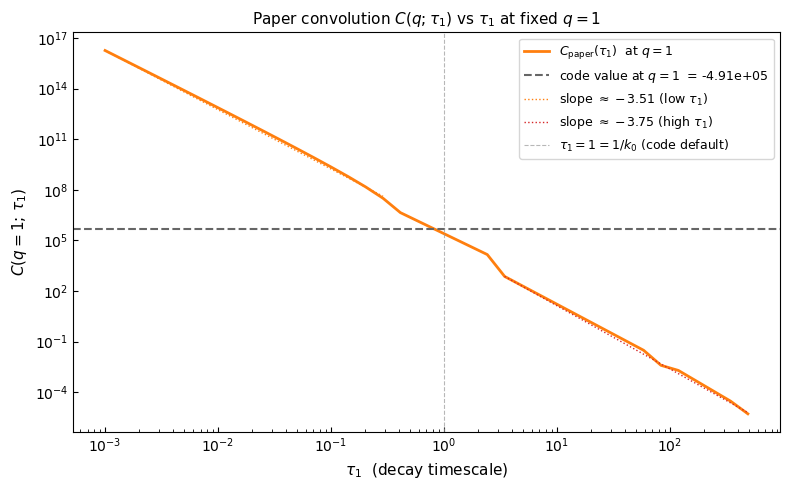

Saved: tau1_limit_scan.pdf

τ₁ regime summary:
      τ₁         C_paper    C_paper/C_code  regime
   0.001      1.8113e+16  36865997931.3691  strongly dec.
   0.100      2.2758e+09         4631.8672  weakly dec.
  10.000     -2.9370e+01           -0.0001  weakly dec.
1000.000     -4.0387e-07           -0.0000  weakly dec.


In [8]:
# ── Scan tau1 from very small to very large at fixed q=1.0 ───────────────────
q_test   = 1.0
tau1_arr = np.logspace(-3, 3, 40)

print(f'Scanning τ₁ at fixed q={q_test} …')
C_paper_scan = np.array([convolution_paper(q_test, tau1=t, n_pts=250) for t in tau1_arr])
C_code_ref_q = convolution_code(q_test, x=1.0, y=1.0, M=1.0, n_pts=250)

fig, ax = plt.subplots(figsize=(8, 5))

valid = C_paper_scan > 0
ax.loglog(tau1_arr[valid], C_paper_scan[valid], color='C1', lw=2.0,
          label=r'$C_{\rm paper}(\tau_1)$  at $q=1$')
ax.axhline(abs(C_code_ref_q), color='0.4', lw=1.5, ls='--',
           label=fr'code value at $q=1$  = {C_code_ref_q:.2e}')

# Power-law guides
tau1_lo = tau1_arr[tau1_arr < 0.3]
if len(tau1_lo) > 3 and np.all(C_paper_scan[tau1_arr < 0.3] > 0):
    # Fit slope in log-log space
    slope_lo = np.polyfit(np.log10(tau1_lo),
                           np.log10(C_paper_scan[tau1_arr < 0.3]), 1)[0]
    ax.loglog(tau1_lo, C_paper_scan[tau1_arr < 0.3][0] * (tau1_lo / tau1_lo[0])**slope_lo,
              color='C1', lw=1.0, ls=':', label=fr'slope $\approx {slope_lo:.2f}$ (low $\tau_1$)')

tau1_hi = tau1_arr[tau1_arr > 3.0]
if len(tau1_hi) > 3 and np.any(C_paper_scan[tau1_arr > 3.0] > 0):
    idx_hi = tau1_arr > 3.0
    valid_hi = idx_hi & valid
    if valid_hi.sum() > 2:
        slope_hi = np.polyfit(np.log10(tau1_arr[valid_hi]),
                               np.log10(C_paper_scan[valid_hi]), 1)[0]
        ax.loglog(tau1_arr[valid_hi],
                  C_paper_scan[valid_hi][0] * (tau1_arr[valid_hi] / tau1_arr[valid_hi][0])**slope_hi,
                  color='C3', lw=1.0, ls=':', label=fr'slope $\approx {slope_hi:.2f}$ (high $\tau_1$)')

ax.axvline(1.0, color='0.6', lw=0.8, ls='--', alpha=0.7,
           label=r'$\tau_1 = 1 = 1/k_0$ (code default)')

ax.set_xlabel(r'$\tau_1$  (decay timescale)', fontsize=11)
ax.set_ylabel(r'$C(q=1;\,\tau_1)$', fontsize=11)
ax.set_title(r'Paper convolution $C(q;\tau_1)$ vs $\tau_1$ at fixed $q=1$', fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_limit_scan.pdf'))
print('Saved: tau1_limit_scan.pdf')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print('τ₁ regime summary:')
print(f'{"τ₁":>8}  {"C_paper":>14}  {"C_paper/C_code":>16}  regime')
for t, c in zip(tau1_arr, C_paper_scan):
    if t in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
        regime = ('strongly dec.' if t < 0.1 else
                  'reference'    if abs(t-1) < 0.01 else
                  'weakly dec.')
        print(f'{t:8.3f}  {c:14.4e}  {c/abs(C_code_ref_q):16.4f}  {regime}')

## 6. Summary and recommendations

### Current status

1. **Kernel formula fixed**: `core.py` now uses the same
   $(-iq)^{-5/3}\Gamma(1/3,-iq)$ kernel as `derivation.tex`.
2. **Convolution domain fixed**: the standalone decay convolution is now evaluated over the full
   real $q_1$ line (with a symmetric finite cutoff in the notebook diagnostics).
3. **Model difference remains**: `H_pq_decaying` still feeds `g_decaying` scale-dependent
   arguments $q_1\sqrt{x}/M$ and $(q-q_1)\sqrt{y}/M$ rather than a single free global $\tau_1$.

### Interpretation

- The notebook's remaining comparison is therefore about **global-$\tau_1$ vs local-turnover-time**
  modelling, not about an implementation bug in the special function itself.
- If the goal is strict agreement with the derivation's global-$\tau_1$ form, `H_pq_decaying`
  would need a physics-level refactor rather than a small kernel patch.
